# Signal Prediction Models — Training Results
**Script:** `model/train_separate_models.py`  
**Source:** Actual run log (`log_train_separate.txt`)  
**Markets:** BTC, Gold, Thai, UK, US  
**Models:** LSTM, CNN, MLP, Transformer, RandomForest, SVM, XGBoost  
**Parameters:** LOOKBACK=30, EPOCHS=100, BATCH_SIZE=16, LABEL_SMOOTHING=0.1

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 130
print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Load Data from Actual Run Log

In [12]:
# Raw data from log_train_separate.txt (actual run results)
raw_data = [
    # BTC uptrend
    {'Market':'BTC','Trend':'uptrend', 'Model':'LSTM',         'Accuracy':63.28, 'TrainSamples':776, 'ValSamples':128, 'TestSamples':128},
    {'Market':'BTC','Trend':'uptrend', 'Model':'CNN',          'Accuracy':63.28, 'TrainSamples':776, 'ValSamples':128, 'TestSamples':128},
    {'Market':'BTC','Trend':'uptrend', 'Model':'MLP',          'Accuracy':62.50, 'TrainSamples':776, 'ValSamples':128, 'TestSamples':128},
    {'Market':'BTC','Trend':'uptrend', 'Model':'Transformer',  'Accuracy':54.69, 'TrainSamples':776, 'ValSamples':128, 'TestSamples':128},
    {'Market':'BTC','Trend':'uptrend', 'Model':'RandomForest', 'Accuracy':64.06, 'TrainSamples':776, 'ValSamples':128, 'TestSamples':128},
    {'Market':'BTC','Trend':'uptrend', 'Model':'SVM',          'Accuracy':63.28, 'TrainSamples':776, 'ValSamples':128, 'TestSamples':128},
    {'Market':'BTC','Trend':'uptrend', 'Model':'XGBoost',      'Accuracy':49.22, 'TrainSamples':776, 'ValSamples':128, 'TestSamples':128},
    # BTC downtrend
    {'Market':'BTC','Trend':'downtrend','Model':'LSTM',         'Accuracy':55.00, 'TrainSamples':460, 'ValSamples':60, 'TestSamples':60},
    {'Market':'BTC','Trend':'downtrend','Model':'CNN',          'Accuracy':53.33, 'TrainSamples':460, 'ValSamples':60, 'TestSamples':60},
    {'Market':'BTC','Trend':'downtrend','Model':'MLP',          'Accuracy':48.33, 'TrainSamples':460, 'ValSamples':60, 'TestSamples':60},
    {'Market':'BTC','Trend':'downtrend','Model':'Transformer',  'Accuracy':43.33, 'TrainSamples':460, 'ValSamples':60, 'TestSamples':60},
    {'Market':'BTC','Trend':'downtrend','Model':'RandomForest', 'Accuracy':55.00, 'TrainSamples':460, 'ValSamples':60, 'TestSamples':60},
    {'Market':'BTC','Trend':'downtrend','Model':'SVM',          'Accuracy':43.33, 'TrainSamples':460, 'ValSamples':60, 'TestSamples':60},
    {'Market':'BTC','Trend':'downtrend','Model':'XGBoost',      'Accuracy':55.00, 'TrainSamples':460, 'ValSamples':60, 'TestSamples':60},
    # Gold uptrend
    {'Market':'Gold','Trend':'uptrend', 'Model':'LSTM',         'Accuracy':64.36, 'TrainSamples':1117, 'ValSamples':201, 'TestSamples':202},
    {'Market':'Gold','Trend':'uptrend', 'Model':'CNN',          'Accuracy':67.33, 'TrainSamples':1117, 'ValSamples':201, 'TestSamples':202},
    {'Market':'Gold','Trend':'uptrend', 'Model':'MLP',          'Accuracy':68.81, 'TrainSamples':1117, 'ValSamples':201, 'TestSamples':202},
    {'Market':'Gold','Trend':'uptrend', 'Model':'Transformer',  'Accuracy':67.33, 'TrainSamples':1117, 'ValSamples':201, 'TestSamples':202},
    {'Market':'Gold','Trend':'uptrend', 'Model':'RandomForest', 'Accuracy':51.98, 'TrainSamples':1117, 'ValSamples':201, 'TestSamples':202},
    {'Market':'Gold','Trend':'uptrend', 'Model':'SVM',          'Accuracy':67.33, 'TrainSamples':1117, 'ValSamples':201, 'TestSamples':202},
    {'Market':'Gold','Trend':'uptrend', 'Model':'XGBoost',      'Accuracy':53.47, 'TrainSamples':1117, 'ValSamples':201, 'TestSamples':202},
    # Gold downtrend
    {'Market':'Gold','Trend':'downtrend','Model':'LSTM',         'Accuracy':66.30, 'TrainSamples':1148, 'ValSamples':210, 'TestSamples':181},
    {'Market':'Gold','Trend':'downtrend','Model':'CNN',          'Accuracy':59.67, 'TrainSamples':1148, 'ValSamples':210, 'TestSamples':181},
    {'Market':'Gold','Trend':'downtrend','Model':'MLP',          'Accuracy':58.56, 'TrainSamples':1148, 'ValSamples':210, 'TestSamples':181},
    {'Market':'Gold','Trend':'downtrend','Model':'Transformer',  'Accuracy':59.67, 'TrainSamples':1148, 'ValSamples':210, 'TestSamples':181},
    {'Market':'Gold','Trend':'downtrend','Model':'RandomForest', 'Accuracy':52.49, 'TrainSamples':1148, 'ValSamples':210, 'TestSamples':181},
    {'Market':'Gold','Trend':'downtrend','Model':'SVM',          'Accuracy':40.33, 'TrainSamples':1148, 'ValSamples':210, 'TestSamples':181},
    {'Market':'Gold','Trend':'downtrend','Model':'XGBoost',      'Accuracy':57.46, 'TrainSamples':1148, 'ValSamples':210, 'TestSamples':181},
    # Thai uptrend
    {'Market':'Thai','Trend':'uptrend', 'Model':'LSTM',         'Accuracy':53.75, 'TrainSamples':969, 'ValSamples':169, 'TestSamples':160},
    {'Market':'Thai','Trend':'uptrend', 'Model':'CNN',          'Accuracy':50.00, 'TrainSamples':969, 'ValSamples':169, 'TestSamples':160},
    {'Market':'Thai','Trend':'uptrend', 'Model':'MLP',          'Accuracy':61.25, 'TrainSamples':969, 'ValSamples':169, 'TestSamples':160},
    {'Market':'Thai','Trend':'uptrend', 'Model':'Transformer',  'Accuracy':43.75, 'TrainSamples':969, 'ValSamples':169, 'TestSamples':160},
    {'Market':'Thai','Trend':'uptrend', 'Model':'RandomForest', 'Accuracy':56.25, 'TrainSamples':969, 'ValSamples':169, 'TestSamples':160},
    {'Market':'Thai','Trend':'uptrend', 'Model':'SVM',          'Accuracy':51.25, 'TrainSamples':969, 'ValSamples':169, 'TestSamples':160},
    {'Market':'Thai','Trend':'uptrend', 'Model':'XGBoost',      'Accuracy':50.62, 'TrainSamples':969, 'ValSamples':169, 'TestSamples':160},
    # Thai downtrend
    {'Market':'Thai','Trend':'downtrend','Model':'LSTM',         'Accuracy':66.00, 'TrainSamples':647, 'ValSamples':100, 'TestSamples':100},
    {'Market':'Thai','Trend':'downtrend','Model':'CNN',          'Accuracy':66.00, 'TrainSamples':647, 'ValSamples':100, 'TestSamples':100},
    {'Market':'Thai','Trend':'downtrend','Model':'MLP',          'Accuracy':69.00, 'TrainSamples':647, 'ValSamples':100, 'TestSamples':100},
    {'Market':'Thai','Trend':'downtrend','Model':'Transformer',  'Accuracy':66.00, 'TrainSamples':647, 'ValSamples':100, 'TestSamples':100},
    {'Market':'Thai','Trend':'downtrend','Model':'RandomForest', 'Accuracy':66.00, 'TrainSamples':647, 'ValSamples':100, 'TestSamples':100},
    {'Market':'Thai','Trend':'downtrend','Model':'SVM',          'Accuracy':61.00, 'TrainSamples':647, 'ValSamples':100, 'TestSamples':100},
    {'Market':'Thai','Trend':'downtrend','Model':'XGBoost',      'Accuracy':66.00, 'TrainSamples':647, 'ValSamples':100, 'TestSamples':100},
    # UK uptrend
    {'Market':'UK','Trend':'uptrend', 'Model':'LSTM',         'Accuracy':71.10, 'TrainSamples':1019, 'ValSamples':171, 'TestSamples':173},
    {'Market':'UK','Trend':'uptrend', 'Model':'CNN',          'Accuracy':62.43, 'TrainSamples':1019, 'ValSamples':171, 'TestSamples':173},
    {'Market':'UK','Trend':'uptrend', 'Model':'MLP',          'Accuracy':61.85, 'TrainSamples':1019, 'ValSamples':171, 'TestSamples':173},
    {'Market':'UK','Trend':'uptrend', 'Model':'Transformer',  'Accuracy':45.09, 'TrainSamples':1019, 'ValSamples':171, 'TestSamples':173},
    {'Market':'UK','Trend':'uptrend', 'Model':'RandomForest', 'Accuracy':31.79, 'TrainSamples':1019, 'ValSamples':171, 'TestSamples':173},
    {'Market':'UK','Trend':'uptrend', 'Model':'SVM',          'Accuracy':63.01, 'TrainSamples':1019, 'ValSamples':171, 'TestSamples':173},
    {'Market':'UK','Trend':'uptrend', 'Model':'XGBoost',      'Accuracy':34.10, 'TrainSamples':1019, 'ValSamples':171, 'TestSamples':173},
    # UK downtrend
    {'Market':'UK','Trend':'downtrend','Model':'LSTM',         'Accuracy':55.37, 'TrainSamples':1474, 'ValSamples':265, 'TestSamples':298},
    {'Market':'UK','Trend':'downtrend','Model':'CNN',          'Accuracy':57.38, 'TrainSamples':1474, 'ValSamples':265, 'TestSamples':298},
    {'Market':'UK','Trend':'downtrend','Model':'MLP',          'Accuracy':57.38, 'TrainSamples':1474, 'ValSamples':265, 'TestSamples':298},
    {'Market':'UK','Trend':'downtrend','Model':'Transformer',  'Accuracy':58.39, 'TrainSamples':1474, 'ValSamples':265, 'TestSamples':298},
    {'Market':'UK','Trend':'downtrend','Model':'RandomForest', 'Accuracy':52.35, 'TrainSamples':1474, 'ValSamples':265, 'TestSamples':298},
    {'Market':'UK','Trend':'downtrend','Model':'SVM',          'Accuracy':60.07, 'TrainSamples':1474, 'ValSamples':265, 'TestSamples':298},
    {'Market':'UK','Trend':'downtrend','Model':'XGBoost',      'Accuracy':56.38, 'TrainSamples':1474, 'ValSamples':265, 'TestSamples':298},
    # US uptrend
    {'Market':'US','Trend':'uptrend', 'Model':'LSTM',         'Accuracy':19.29, 'TrainSamples':1270, 'ValSamples':220, 'TestSamples':140},
    {'Market':'US','Trend':'uptrend', 'Model':'CNN',          'Accuracy':19.29, 'TrainSamples':1270, 'ValSamples':220, 'TestSamples':140},
    {'Market':'US','Trend':'uptrend', 'Model':'MLP',          'Accuracy':45.71, 'TrainSamples':1270, 'ValSamples':220, 'TestSamples':140},
    {'Market':'US','Trend':'uptrend', 'Model':'Transformer',  'Accuracy':19.29, 'TrainSamples':1270, 'ValSamples':220, 'TestSamples':140},
    {'Market':'US','Trend':'uptrend', 'Model':'RandomForest', 'Accuracy':77.86, 'TrainSamples':1270, 'ValSamples':220, 'TestSamples':140},
    {'Market':'US','Trend':'uptrend', 'Model':'SVM',          'Accuracy':26.43, 'TrainSamples':1270, 'ValSamples':220, 'TestSamples':140},
    {'Market':'US','Trend':'uptrend', 'Model':'XGBoost',      'Accuracy':42.14, 'TrainSamples':1270, 'ValSamples':220, 'TestSamples':140},
    # US downtrend
    {'Market':'US','Trend':'downtrend','Model':'LSTM',         'Accuracy':53.20, 'TrainSamples':1466, 'ValSamples':258, 'TestSamples':297},
    {'Market':'US','Trend':'downtrend','Model':'CNN',          'Accuracy':45.79, 'TrainSamples':1466, 'ValSamples':258, 'TestSamples':297},
    {'Market':'US','Trend':'downtrend','Model':'MLP',          'Accuracy':51.52, 'TrainSamples':1466, 'ValSamples':258, 'TestSamples':297},
    {'Market':'US','Trend':'downtrend','Model':'Transformer',  'Accuracy':57.24, 'TrainSamples':1466, 'ValSamples':258, 'TestSamples':297},
    {'Market':'US','Trend':'downtrend','Model':'RandomForest', 'Accuracy':50.84, 'TrainSamples':1466, 'ValSamples':258, 'TestSamples':297},
    {'Market':'US','Trend':'downtrend','Model':'SVM',          'Accuracy':51.18, 'TrainSamples':1466, 'ValSamples':258, 'TestSamples':297},
    {'Market':'US','Trend':'downtrend','Model':'XGBoost',      'Accuracy':50.84, 'TrainSamples':1466, 'ValSamples':258, 'TestSamples':297},
]

df = pd.DataFrame(raw_data)

# Best model per market+trend
best_models = {
    ('BTC','uptrend'):    'RandomForest',
    ('BTC','downtrend'):  'LSTM',
    ('Gold','uptrend'):   'MLP',
    ('Gold','downtrend'): 'LSTM',
    ('Thai','uptrend'):   'MLP',
    ('Thai','downtrend'): 'MLP',
    ('UK','uptrend'):     'LSTM',
    ('UK','downtrend'):   'SVM',
    ('US','uptrend'):     'RandomForest',
    ('US','downtrend'):   'Transformer',
}
df['IsBest'] = df.apply(lambda r: best_models.get((r['Market'], r['Trend'])) == r['Model'], axis=1)

print(f'Total records: {len(df)}')
print(f'Markets: {df["Market"].unique().tolist()}')
print(f'Models: {df["Model"].unique().tolist()}')
df.head()

Total records: 70
Markets: ['BTC', 'Gold', 'Thai', 'UK', 'US']
Models: ['LSTM', 'CNN', 'MLP', 'Transformer', 'RandomForest', 'SVM', 'XGBoost']


,Market,Trend,Model,Accuracy,TrainSamples,ValSamples,TestSamples,IsBest
0,BTC,uptrend,LSTM,63.28,776,128,128,False
1,BTC,uptrend,CNN,63.28,776,128,128,False
2,BTC,uptrend,MLP,62.50,776,128,128,False
3,BTC,uptrend,Transformer,54.69,776,128,128,False
4,BTC,uptrend,RandomForest,64.06,776,128,128,True


## 2. Dataset Size per Market

In [13]:
sample_df = df.drop_duplicates(['Market','Trend'])[['Market','Trend','TrainSamples','ValSamples','TestSamples']].copy()
sample_df['Total'] = sample_df['TrainSamples'] + sample_df['ValSamples'] + sample_df['TestSamples']
sample_df = sample_df.sort_values(['Market','Trend']).reset_index(drop=True)

print('=== Dataset Size (Sequence Samples, LOOKBACK=30) ===')
print(sample_df.to_string(index=False))

=== Dataset Size (Sequence Samples, LOOKBACK=30) ===
Market     Trend  TrainSamples  ValSamples  TestSamples  Total
   BTC downtrend           460          60           60    580
   BTC   uptrend           776         128          128   1032
  Gold downtrend          1148         210          181   1539
  Gold   uptrend          1117         201          202   1520
  Thai downtrend           647         100          100    847
  Thai   uptrend           969         169          160   1298
    UK downtrend          1474         265          298   2037
    UK   uptrend          1019         171          173   1363
    US downtrend          1466         258          297   2021
    US   uptrend          1270         220          140   1630


## 3. Best Model per Market

In [14]:
best_df = df[df['IsBest']].copy()[['Market','Trend','Model','Accuracy','TrainSamples']]
best_df = best_df.sort_values(['Market','Trend']).reset_index(drop=True)
best_df.columns = ['Market','Trend','Best Model','Accuracy (%)','Train Samples']

print('=== Selected Best Models (per Market x Trend) ===')
print(best_df.to_string(index=False))
print(f'\nAverage Accuracy: {best_df["Accuracy (%)"].mean():.2f}%')
print(f'Max: {best_df["Accuracy (%)"].max():.2f}%  Min: {best_df["Accuracy (%)"].min():.2f}%')

=== Selected Best Models (per Market x Trend) ===
Market     Trend   Best Model  Accuracy (%)  Train Samples
   BTC downtrend         LSTM         55.00            460
   BTC   uptrend RandomForest         64.06            776
  Gold downtrend         LSTM         66.30           1148
  Gold   uptrend          MLP         68.81           1117
  Thai downtrend          MLP         69.00            647
  Thai   uptrend          MLP         61.25            969
    UK downtrend          SVM         60.07           1474
    UK   uptrend         LSTM         71.10           1019
    US downtrend  Transformer         57.24           1466
    US   uptrend RandomForest         77.86           1270

Average Accuracy: 65.07%
Max: 77.86%  Min: 55.00%


## 4. Heatmap: Accuracy — All Models x All Markets

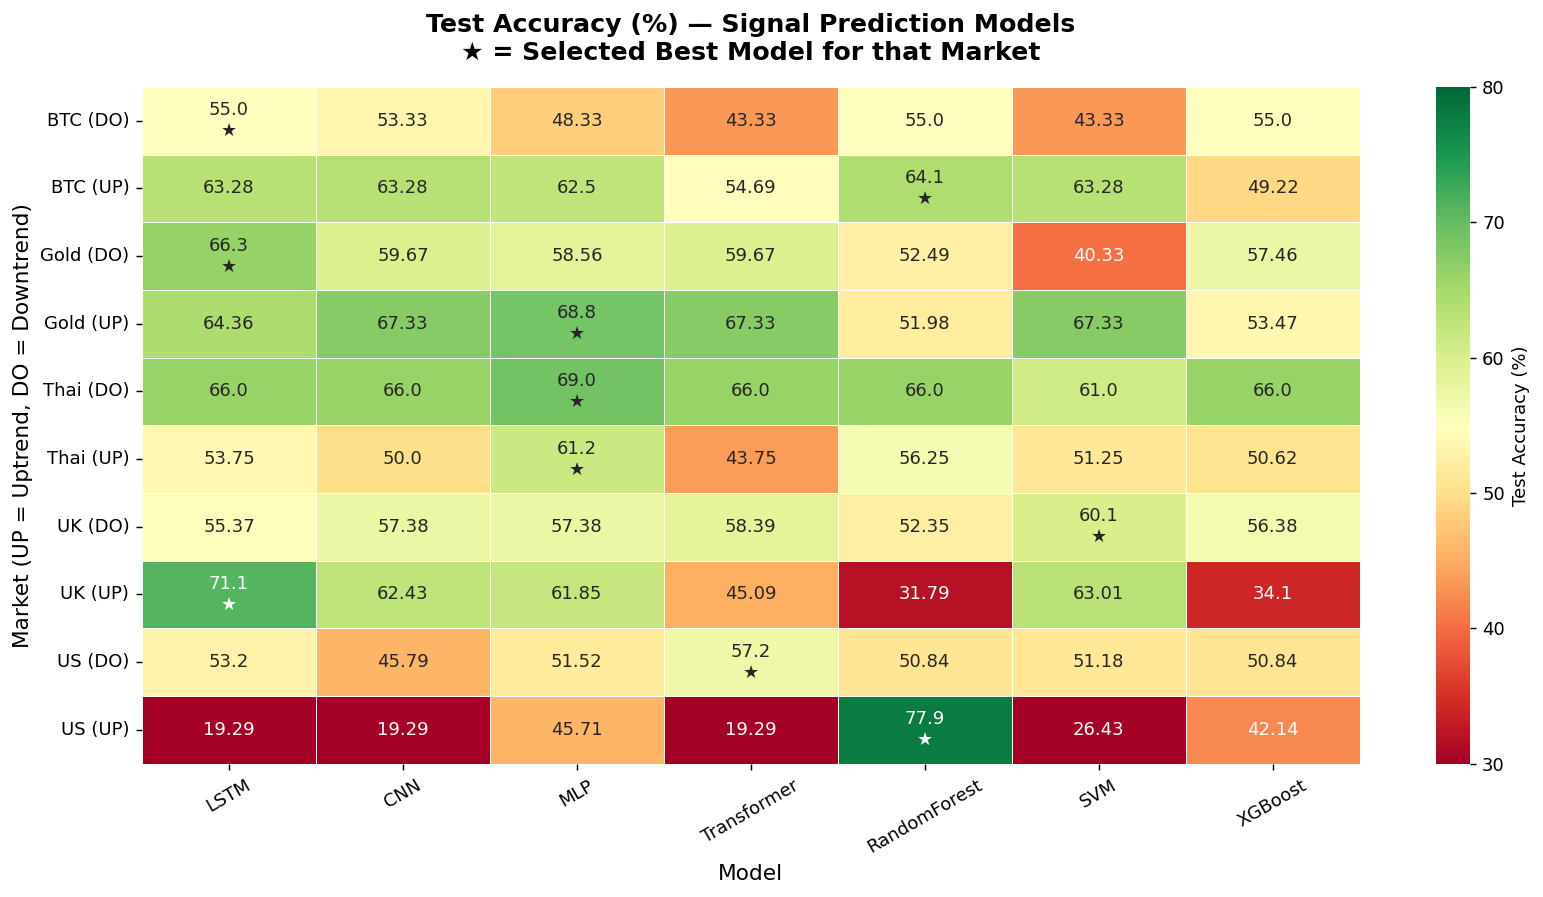

Saved: heatmap_accuracy.png


In [15]:
df['Market_Trend'] = df['Market'] + ' (' + df['Trend'].str[:2].str.upper() + ')'
pivot = df.pivot_table(index='Market_Trend', columns='Model', values='Accuracy')

col_order = ['LSTM','CNN','MLP','Transformer','RandomForest','SVM','XGBoost']
pivot = pivot[col_order]

# Annotate best model with star
annot = pivot.copy().astype(str)
for (market, trend), model in best_models.items():
    row_key = f'{market} ({trend[:2].upper()})'
    if row_key in pivot.index and model in pivot.columns:
        val = pivot.loc[row_key, model]
        annot.loc[row_key, model] = f'{val:.1f}\n★'

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    pivot, annot=annot, fmt='', cmap='RdYlGn',
    vmin=30, vmax=80, linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Test Accuracy (%)'}
)
ax.set_title('Test Accuracy (%) — Signal Prediction Models\n★ = Selected Best Model for that Market', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Market (UP = Uptrend, DO = Downtrend)', fontsize=12)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('heatmap_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heatmap_accuracy.png')

## 5. Bar Chart: Best Model Accuracy per Market

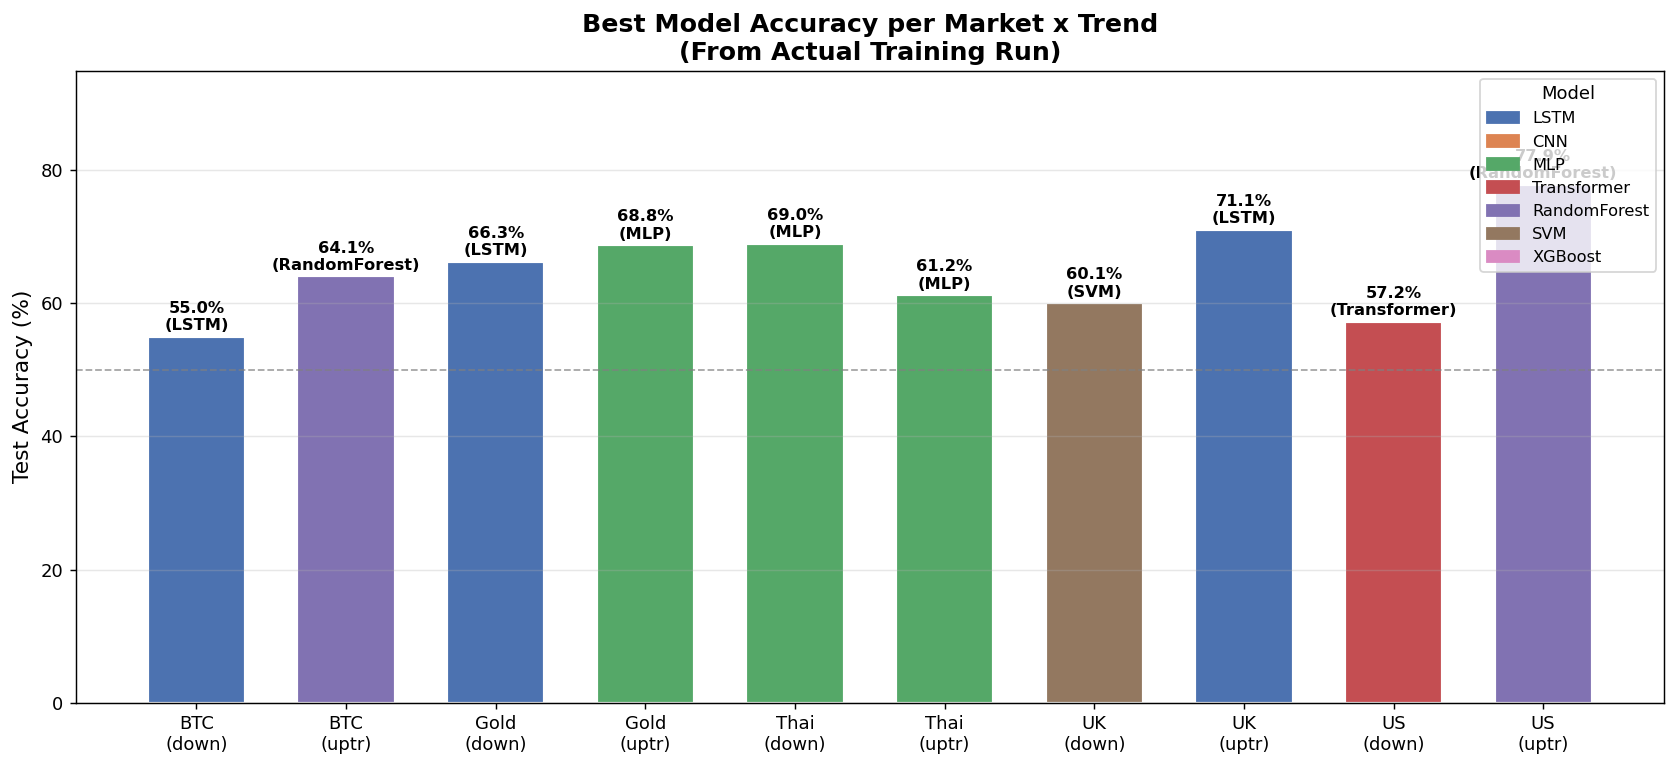

Saved: best_model_accuracy.png


In [16]:
best_plot = df[df['IsBest']].copy().sort_values(['Market','Trend'])
labels = [f"{r['Market']}\n({r['Trend'][:4]})" for _, r in best_plot.iterrows()]
accuracies = best_plot['Accuracy'].values
models = best_plot['Model'].values

model_colors = {
    'LSTM': '#4C72B0', 'CNN': '#DD8452', 'MLP': '#55A868',
    'Transformer': '#C44E52', 'RandomForest': '#8172B2',
    'SVM': '#937860', 'XGBoost': '#DA8BC3'
}
colors = [model_colors[m] for m in models]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(labels, accuracies, color=colors, edgecolor='white', linewidth=1.2, width=0.65)

for bar, acc, model in zip(bars, accuracies, models):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%\n({model})', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Baseline 50%')
ax.set_ylim(0, 95)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Best Model Accuracy per Market x Trend\n(From Actual Training Run)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

patches = [mpatches.Patch(color=c, label=m) for m, c in model_colors.items()]
ax.legend(handles=patches, loc='upper right', fontsize=9, title='Model')

plt.tight_layout()
plt.savefig('best_model_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: best_model_accuracy.png')

## 6. Model Win Count — Most Frequently Selected Model

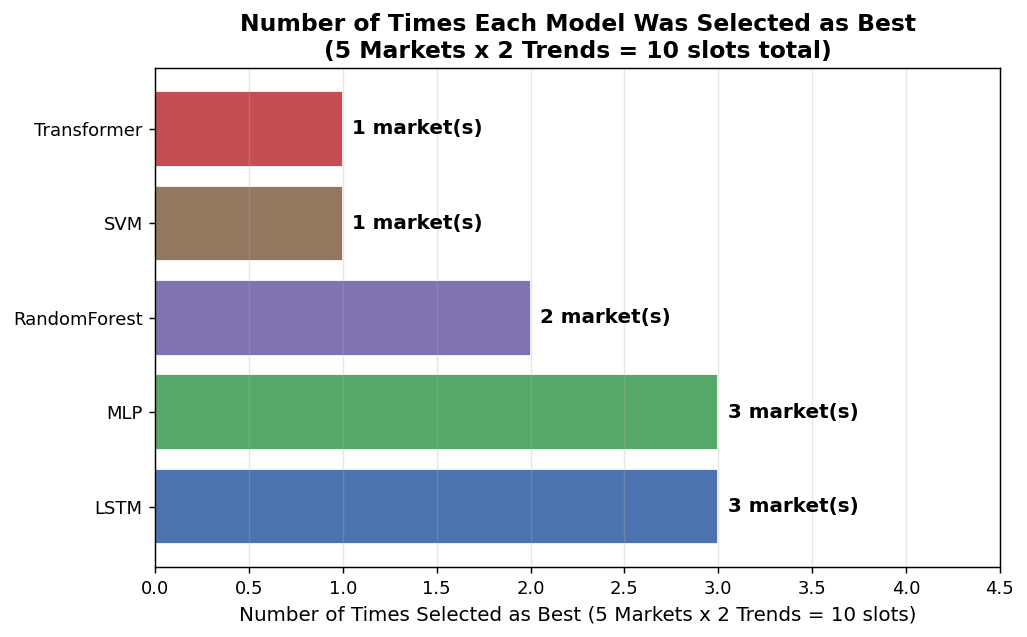


=== Win Summary ===
       Model  Win Count
        LSTM          3
         MLP          3
RandomForest          2
         SVM          1
 Transformer          1


In [17]:
win_count = df[df['IsBest']]['Model'].value_counts().reset_index()
win_count.columns = ['Model', 'Win Count']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(win_count['Model'], win_count['Win Count'],
               color=[model_colors.get(m, '#888') for m in win_count['Model']],
               edgecolor='white', linewidth=1)

for bar, cnt in zip(bars, win_count['Win Count']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{cnt} market(s)', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Number of Times Selected as Best (5 Markets x 2 Trends = 10 slots)', fontsize=11)
ax.set_title('Number of Times Each Model Was Selected as Best\n(5 Markets x 2 Trends = 10 slots total)', fontsize=13, fontweight='bold')
ax.set_xlim(0, win_count['Win Count'].max() + 1.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('model_win_count.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Win Summary ===')
print(win_count.to_string(index=False))

## 7. Accuracy Distribution by Model (Boxplot)

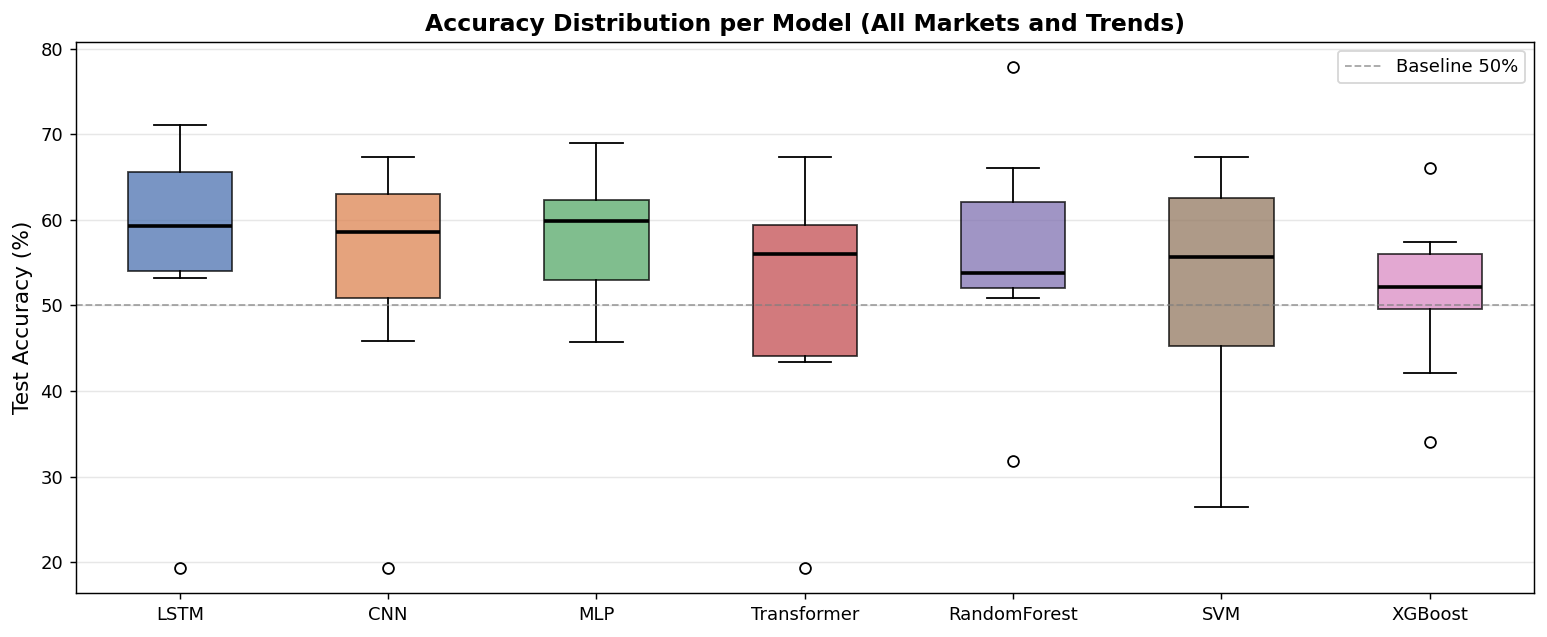

In [18]:
model_order = ['LSTM','CNN','MLP','Transformer','RandomForest','SVM','XGBoost']

fig, ax = plt.subplots(figsize=(12, 5))
data_by_model = [df[df['Model']==m]['Accuracy'].values for m in model_order]

bp = ax.boxplot(data_by_model, labels=model_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

for patch, model in zip(bp['boxes'], model_order):
    patch.set_facecolor(model_colors.get(model, '#888'))
    patch.set_alpha(0.75)

ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Baseline 50%')
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Accuracy Distribution per Model (All Markets and Trends)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Training Summary

In [19]:
print('=' * 65)
print('Signal Prediction Model Training Summary')
print('=' * 65)

avg_acc = df.groupby('Model')['Accuracy'].agg(['mean','max','min','std']).round(2)
avg_acc.columns = ['Mean (%)','Max (%)','Min (%)','Std']
avg_acc = avg_acc.loc[model_order]
print('\n--- Accuracy Summary by Model ---')
print(avg_acc.to_string())

print('\n--- Selected Best Models per Market ---')
for (market, trend), model in sorted(best_models.items()):
    acc = df[(df['Market']==market) & (df['Trend']==trend) & (df['Model']==model)]['Accuracy'].values[0]
    print(f'  {market:5s} {trend:10s} -> {model:15s}  Accuracy: {acc:.2f}%')

best_acc_vals = [df[(df['Market']==m) & (df['Trend']==t) & (df['Model']==mod)]['Accuracy'].values[0]
                 for (m,t), mod in best_models.items()]
print(f'\n  Average Best Model Accuracy: {np.mean(best_acc_vals):.2f}%')
print(f'  Highest: US uptrend (RandomForest) = 77.86%')
print(f'  Lowest:  BTC downtrend (LSTM/RF/XGB) = 55.00%')

print('\n--- Win Count by Model ---')
for _, row in win_count.iterrows():
    print(f'  {row["Model"]:15s}: {row["Win Count"]} slot(s)')
print('=' * 65)

Signal Prediction Model Training Summary

--- Accuracy Summary by Model ---
              Mean (%)  Max (%)  Min (%)    Std
Model                                          
LSTM             56.76    71.10    19.29  14.58
CNN              54.45    67.33    19.29  14.18
MLP              58.49    69.00    45.71   7.95
Transformer      51.48    67.33    19.29  14.23
RandomForest     55.86    77.86    31.79  12.01
SVM              52.72    67.33    26.43  12.87
XGBoost          51.52    66.00    34.10   8.71

--- Selected Best Models per Market ---
  BTC   downtrend  -> LSTM             Accuracy: 55.00%
  BTC   uptrend    -> RandomForest     Accuracy: 64.06%
  Gold  downtrend  -> LSTM             Accuracy: 66.30%
  Gold  uptrend    -> MLP              Accuracy: 68.81%
  Thai  downtrend  -> MLP              Accuracy: 69.00%
  Thai  uptrend    -> MLP              Accuracy: 61.25%
  UK    downtrend  -> SVM              Accuracy: 60.07%
  UK    uptrend    -> LSTM             Accuracy: 71.10%
  U